# 获取模型训练所需要的数据

In [1]:
import baostock as bs
import pandas as pd
import os

def get_pingan_bank_data():
    # 初始化baostock连接
    lg = bs.login()
    # 检查连接是否成功
    if lg.error_code != '0':
        print(f"登录失败: {lg.error_msg}")
        return
    
    try:
        # 平安银行的股票代码是sh.601318
        stock_code = "sz.000001"
        
        # 获取股票基本信息
        stock_basic = bs.query_stock_basic(code=stock_code).get_data()
        
        # 获取历史交易数据，时间范围可以自行调整
        start_date = "2020-01-01"
        end_date = "2023-12-31"
        
        # 获取日线数据
        rs = bs.query_history_k_data_plus(
            stock_code,
            "date,code,open,high,low,close,volume,amount,adjustflag",
            start_date=start_date,
            end_date=end_date,
            frequency="d",
            adjustflag="3"  # 3表示复权
        )
        
        # 将数据转为DataFrame
        data_list = []
        while (rs.error_code == '0') & rs.next():
            data_list.append(rs.get_row_data())
        
        df = pd.DataFrame(
            data_list,
            columns=rs.fields
        )
        
        # 创建data文件夹（如果不存在）
        if not os.path.exists('data'):
            os.makedirs('data')
        
        # 保存基本信息
        stock_basic.to_csv('data/pingan_bank_basic.csv', index=False, encoding='utf-8')
        
        # 保存历史数据
        df.to_csv('data/pingan_bank_data.csv', index=False, encoding='utf-8')
        
        print("数据获取成功，已保存到data文件夹")
        print(f"基本信息文件: data/pingan_bank_basic.csv")
        print(f"历史行情文件: data/pingan_bank_data.csv")
        
    except Exception as e:
        print(f"获取数据出错: {e}")
    finally:
        # 登出baostock
        bs.logout()

if __name__ == "__main__":
    get_pingan_bank_data()
    

ModuleNotFoundError: No module named 'baostock'

## 模型训练

### 分类策略

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score
import joblib
#数据处理
data = pd.read_csv('data/pingan_bank_data.csv')
data["date"] = pd.to_datetime(data["date"])
data.index = data['date']
data.drop(columns=['date','code','adjustflag'],inplace=True)
#创建标签列
data['Label'] = data['close'].diff().gt(0).astype(int)
#提取特征和目标的变量
x = data[['volume','open','high','low']]
y = data['Label']
#规划训练集和测试集
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.3,random_state=1)
#构建pipline
pipe = Pipeline([
    ('imputer',SimpleImputer(strategy='mean')),
    ('scaler',StandardScaler()),
    ('model',LogisticRegression())
])
#模型训练
pipe.fit(x_train,y_train)
#保存模型
joblib.dump(pipe,'model.pkl')
#测试集预测
y_pred = pipe.predict(x_test)
#准确率
accuracy = accuracy_score(y_test,y_pred)
print('准确率:',accuracy)

准确率: 0.6838487972508591


#### 使用模型进行预测

In [2]:
import pandas as pd
import numpy as np

# 设置随机种子，确保数据可复现
np.random.seed(42)

# 生成5000条数据
n_samples = 5000

# 基于平安银行历史数据特征的参数设置
# 1. 成交量(volume)：参考平安银行实际成交量范围（5000万-8亿股）
# 使用对数分布更贴近真实交易情况（多数时间成交量适中，偶尔出现极端值）
volume_log = np.random.uniform(low=np.log(5000000), high=np.log(80000000), size=n_samples)
volume = np.round(np.exp(volume_log)).astype(int)

# 2. 开盘价(open)：参考平安银行近年股价范围（8-22元）
open_price = np.round(np.random.uniform(low=8.0, high=22.0, size=n_samples), 2)

# 3. 最高价(high)：必须≥开盘价，平安银行单日波动通常在0-3%
high_fluctuation = np.random.uniform(low=1.0, high=1.03, size=n_samples)
high_price = np.round(open_price * high_fluctuation, 2)

# 4. 最低价(low)：必须≤开盘价，平安银行单日波动通常在0-3%
low_fluctuation = np.random.uniform(low=0.97, high=1.0, size=n_samples)
low_price = np.round(open_price * low_fluctuation, 2)

# 5. 生成合理的交易日序列（排除周末和节假日逻辑简化版）
start_date = pd.to_datetime('2020-01-01')
dates = []
current_date = start_date

while len(dates) < n_samples:
    # 只保留周一到周五（0-4代表周一到周五）
    if current_date.weekday() < 5:
        dates.append(current_date)
    current_date += pd.Timedelta(days=1)

# 构造DataFrame，包含日期和所需特征
pingan_like_data = pd.DataFrame({
    'date': dates,
    'volume': volume,
    'open': open_price,
    'high': high_price,
    'low': low_price
})

# 额外计算并添加收盘价（参考平安银行开盘价与收盘价关系）
# 收盘价在最低价和最高价之间，且与开盘价差异通常在±2%以内
close_fluctuation = np.random.uniform(low=-0.02, high=0.02, size=n_samples)
pingan_like_data['close'] = np.round(
    open_price * (1 + close_fluctuation), 2
)

# 确保收盘价在[low, high]区间内（修正极端情况）
pingan_like_data['close'] = pingan_like_data.apply(
    lambda row: max(min(row['close'], row['high']), row['low']), axis=1
)

# 保存为CSV文件
pingan_like_data.to_csv('pingan_bank_like_data_5000.csv', index=False, encoding='utf-8')

# 展示数据信息
print("生成的平安银行类似特征数据集（前5条）：")
print(pingan_like_data.head())
print(f"\n数据总量：{len(pingan_like_data)}条")
print(f"价格范围：{pingan_like_data['open'].min():.2f} - {pingan_like_data['open'].max():.2f}元")
print(f"成交量范围：{pingan_like_data['volume'].min()} - {pingan_like_data['volume'].max()}股")
print(f"数据已保存至：pingan_bank_like_data_5000.csv") 

生成的平安银行类似特征数据集（前5条）：
        date    volume   open   high    low  close
0 2020-01-01  14124115  13.51  13.66  13.31  13.63
1 2020-01-02  69782110  14.63  14.78  14.52  14.52
2 2020-01-03  38052092  19.96  20.07  19.70  19.84
3 2020-01-06  26292183  12.76  12.99  12.41  12.84
4 2020-01-07   7706109  20.18  20.47  19.69  20.17

数据总量：5000条
价格范围：8.00 - 21.99元
成交量范围：5000161 - 79937402股
数据已保存至：pingan_bank_like_data_5000.csv


In [3]:
import pandas as pd
import joblib
#加载模型和数据
loaded_model = joblib.load('model.pkl')
data = pd.read_csv('pingan_bank_like_data_5000.csv')
#提取特征并预测
features = data[['volume', 'open', 'high', 'low']]
predicted_labels = loaded_model.predict(features)
#计算真实标签（根据收盘价与开盘价的关系：close > open 则为上涨）
data['真实标签'] = (data['close'] > data['open']).astype(int)  # 1=上涨，0=下跌
#对比预测结果与真实标签，统计预测成功的个数
data['预测正确'] = (data['真实标签'] == predicted_labels)
success_count = data['预测正确'].sum()  # 预测成功的总个数
total_count = len(data)  # 总样本数
accuracy = success_count / total_count  # 准确率
data['预测标签'] = predicted_labels
#然后再进行打印
print(data[['date', 'open', 'close', '真实标签', '预测标签']].head(10))
#输出结果
print(f"总样本数：{total_count}")
print(f"预测成功的个数：{success_count}")
print(f"预测成功率：{accuracy:.2%}")  # 百分比格式显示

         date   open  close  真实标签  预测标签
0  2020-01-01  13.51  13.63     1     0
1  2020-01-02  14.63  14.52     0     0
2  2020-01-03  19.96  19.84     0     0
3  2020-01-06  12.76  12.84     1     0
4  2020-01-07  20.18  20.17     0     0
5  2020-01-08   9.23   9.32     1     0
6  2020-01-09  18.88  18.90     1     0
7  2020-01-10  19.87  19.61     0     0
8  2020-01-13  10.55  10.64     1     0
9  2020-01-14  14.02  13.87     0     0
总样本数：5000
预测成功的个数：2507
预测成功率：50.14%


### 回归策略

In [4]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import joblib
#数据处理
data = pd.read_csv('data/pingan_bank_data.csv')
data["date"] = pd.to_datetime(data["date"])
data.index = data['date']
data.drop(columns=['date','code','adjustflag'],inplace=True)
#提取特征和目标的变量
x = data[['volume','open','high','low']]
y = data['close']
#规划训练集和测试集
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.3,random_state=1)
#模型训练
model = LinearRegression()
model.fit(x_train,y_train)
#测试集预测
y_pred = model.predict(x_test)
#模型评估
mse = mean_squared_error(y_test,y_pred)
print(f'均方误差(MSE):{mse}')
#保存模型数据
joblib.dump(model,'model2.kpl')

均方误差(MSE):0.019026375075141443


['model2.kpl']

#### 预测股票走势

In [5]:
import pandas as pd
import joblib
#加载模型
loaded_model = joblib.load('model2.kpl')
#新数据
data = pd.read_csv('pingan_bank_like_data_5000.csv')
#删除close与date
data.drop(columns=['date','close'],inplace=True)
#预测结果
predicted_labels = loaded_model.predict(data)
#输出结果
for i,label in enumerate(predicted_labels):
    print(f'样本{i+1}的预测结果:{label}')

样本1的预测结果:13.471394004610014
样本2的预测结果:14.664373206207939
样本3的预测结果:19.86213509215736
样本4的预测结果:12.662982690232626
样本5的预测结果:20.039292363892056
样本6的预测结果:9.231944951291185
样本7的预测结果:18.587291364650415
样本8的预测结果:19.97477854698528
样本9的预测结果:10.602124404405647
样本10的预测结果:14.001776930837291
样本11的预测结果:10.29304792283635
样本12的预测结果:17.857161463259825
样本13的预测结果:15.81472848734189
样本14的预测结果:16.821150204567346
样本15的预测结果:10.835745637564631
样本16的预测结果:10.91832523891593
样本17的预测结果:8.469776719678554
样本18的预测结果:12.4935322169545
样本19的预测结果:15.592722581311431
样本20的预测结果:20.004184110387357
样本21的预测结果:17.12682895617579
样本22的预测结果:14.058762597619818
样本23的预测结果:21.342642791519932
样本24的预测结果:17.993113591407667
样本25的预测结果:20.947157897218762
样本26的预测结果:15.412891000039194
样本27的预测结果:11.672959317765237
样本28的预测结果:8.834101082520368
样本29的预测结果:18.239607467975375
样本30的预测结果:9.70422439962265
样本31的预测结果:12.139652248867554
样本32的预测结果:15.789352842677733
样本33的预测结果:15.868739941349283
样本34的预测结果:16.721437133652906
样本35的预测结果:10.382592237031636
样本36的预测

#### 可视化分析

C:\Users\86157\AppData\Local\Temp\ipykernel_32656\2348384892.py:67: UserWarning: Glyph 25910 (\N{CJK UNIFIED IDEOGRAPH-6536}) missing from font(s) Arial.
  plt.tight_layout()  # 自动调整子图间距，避免标签重叠
C:\Users\86157\AppData\Local\Temp\ipykernel_32656\2348384892.py:67: UserWarning: Glyph 30424 (\N{CJK UNIFIED IDEOGRAPH-76D8}) missing from font(s) Arial.
  plt.tight_layout()  # 自动调整子图间距，避免标签重叠
C:\Users\86157\AppData\Local\Temp\ipykernel_32656\2348384892.py:67: UserWarning: Glyph 20215 (\N{CJK UNIFIED IDEOGRAPH-4EF7}) missing from font(s) Arial.
  plt.tight_layout()  # 自动调整子图间距，避免标签重叠
C:\Users\86157\AppData\Local\Temp\ipykernel_32656\2348384892.py:67: UserWarning: Glyph 20998 (\N{CJK UNIFIED IDEOGRAPH-5206}) missing from font(s) Arial.
  plt.tight_layout()  # 自动调整子图间距，避免标签重叠
C:\Users\86157\AppData\Local\Temp\ipykernel_32656\2348384892.py:67: UserWarning: Glyph 24067 (\N{CJK UNIFIED IDEOGRAPH-5E03}) missing from font(s) Arial.
  plt.tight_layout()  # 自动调整子图间距，避免标签重叠
C:\Users\86157\AppData\Local\T

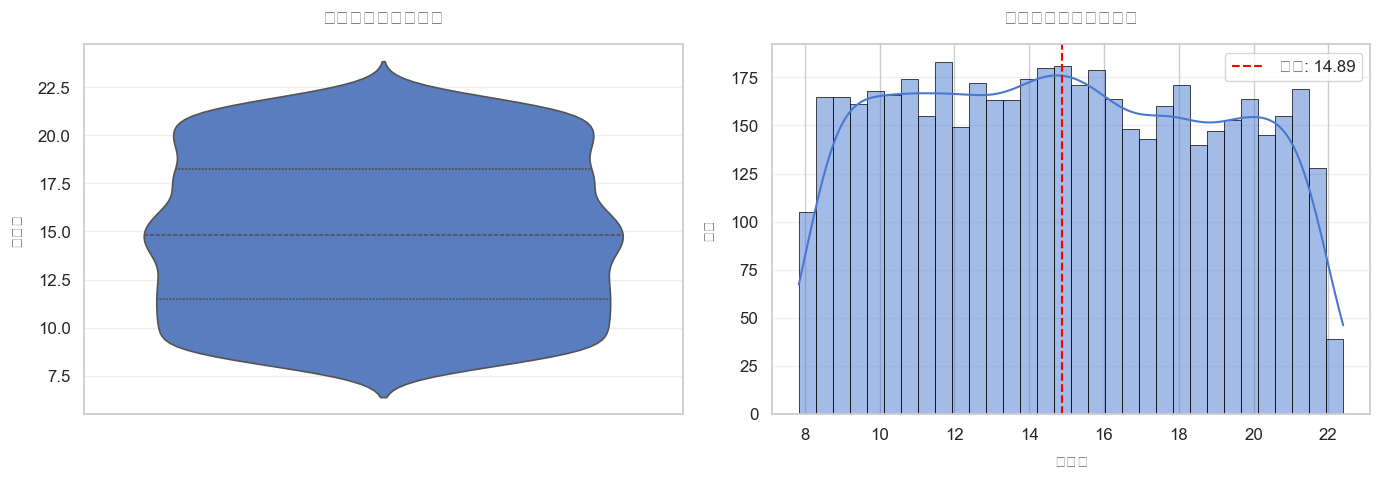

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np  # 用于潜在的数据校验（可选）

# ------------------------------------------------------------------------------
# 1. 数据预处理与校验（避免因数据格式问题导致绘图失败）
# ------------------------------------------------------------------------------
# 确保 predicted_labels 是可绘图的数值类型（如 numpy 数组/列表）
predicted_labels = np.array(predicted_labels)  # 转为 numpy 数组，提升 seaborn 兼容性
# 可选：简单数据校验（避免空值/非数值导致报错）
if np.isnan(predicted_labels).any():
    print("警告：数据中存在空值，已自动剔除")
    predicted_labels = predicted_labels[~np.isnan(predicted_labels)]  # 剔除空值


# ------------------------------------------------------------------------------
# 2. 全局绘图样式配置（提前设置，避免中文乱码+统一风格）
# ------------------------------------------------------------------------------
# 中文支持（兼容 Windows/macOS，避免 SimHei 在 macOS 下失效）
plt.rcParams['font.family']    = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示异常问题

# 设置 seaborn 主题（柔和风格，避免默认白底刺眼）
sns.set_theme(style="whitegrid", palette="muted")  # whitegrid：带网格线，便于读值；muted：低饱和度配色
sns.set_context("notebook", font_scale=1.1)  # 字体缩放（1.1倍），提升可读性


# ------------------------------------------------------------------------------
# 3. 子图布局：小提琴图 + 直方图 横向排列（避免单图冗余，对比更直观）
# ------------------------------------------------------------------------------
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))  # 1行2列子图，总尺寸14x5（宽x高）

# --------------------------
# 子图1：小提琴图（展示分布密度+四分位数）
# --------------------------
sns.violinplot(y=predicted_labels, ax=ax1, inner="quartile", linewidth=1.2)  # inner=quartile：显示四分位数线
ax1.set_title('收盘价分布小提琴图', fontsize=13, pad=15)  # pad=15：标题与图间距
ax1.set_ylabel('收盘价', fontsize=11, labelpad=10)  # labelpad=10：轴标签与轴间距
ax1.grid(axis="y", alpha=0.3)  # y轴网格线（透明度0.3，不遮挡数据）

# --------------------------
# 子图2：直方图（带核密度曲线，展示频数分布）
# --------------------------
# 自定义直方图bins数量（用Freedman-Diaconis规则自动计算，避免bins过多/过少）
bins = int(np.ceil((predicted_labels.max() - predicted_labels.min()) / (2 * predicted_labels.std() / len(predicted_labels)**(1/3))))
sns.histplot(
    data=predicted_labels, 
    kde=True,  # 显示核密度曲线
    bins=bins,  # 自动计算的bins数
    ax=ax2,
    edgecolor="black", linewidth=0.5  # 柱子边缘黑色描边，区分相邻柱子
)
ax2.set_title('收盘价频数分布直方图', fontsize=13, pad=15)
ax2.set_xlabel('收盘价', fontsize=11, labelpad=10)
ax2.set_ylabel('频数', fontsize=11, labelpad=10)
ax2.grid(axis="y", alpha=0.3)

# 可选：在直方图上标注均值线（增强统计信息）
mean_val = predicted_labels.mean()
ax2.axvline(mean_val, color='red', linestyle='--', linewidth=1.5, label=f'均值: {mean_val:.2f}')
ax2.legend()  # 显示均值线标签


# ------------------------------------------------------------------------------
# 4. 整体调整：避免子图拥挤，保存高清图片
# ------------------------------------------------------------------------------
plt.tight_layout()  # 自动调整子图间距，避免标签重叠
plt.savefig('收盘价分布分析图.png', dpi=300, bbox_inches='tight')  # 保存为300dpi高清图（bbox_inches避免标签被截断）
plt.show()  # 显示图片